# CAMPFIRE Python Client — Quickstart

This notebook is the runnable companion to the
[Getting Started](https://campfire.hollisakins.com/docs/api/getting-started)
and [Recipes](https://campfire.hollisakins.com/docs/api/recipes) docs.

**Prerequisites** (run once in your terminal):

```bash
pip install "git+https://github.com/hollisakins/campfire.git#subdirectory=python/"
campfire login
```


In [1]:
from campfire import Campfire

cf = Campfire()
print(f"Local data available: {cf.is_local}")
print(f"Last synced:          {cf.last_synced}")


Local data available: True
Last synced:          2026-04-26T01:09:06.151952+00:00


## 1. Sync the catalog

Pull all metadata you have access to into a local SQLite database. No FITS
files yet — that's a separate step. Sync is fast and safe to run often;
it refreshes inspection results, redshifts, tags, and any new spectra.


In [2]:
result = cf.sync()
print(f"Synced {result['observations']} observations, "
      f"{result['objects']} objects, "
      f"{result['spectra']} spectra")

if result['stale_count'] > 0:
    print(f"\n⚠ {result['stale_count']} local file(s) have been reprocessed on the server.")
    print("  Run: cf.download(stale_only=True)")


Synced 146 observations, 3072 objects, 1101 spectra

⚠ 194 local file(s) have been reprocessed on the server.
  Run: cf.download(stale_only=True)


## 2. Query objects

`query_objects` returns one row per sky position (an `astropy.table.Table`).
Filters can be combined freely; queries run against your local database
and are effectively instant.


In [3]:
# High-redshift galaxies with secure or probable redshifts
high_z = cf.query_objects(
    redshift_range=(5.0, 12.0),
    redshift_quality=['probable', 'secure'],   # or [3, 4]
    inspected_only=True,
)

print(f"Found {len(high_z)} high-z galaxies")
high_z['object_id', 'field', 'redshift', 'redshift_quality', 'max_snr'][:8]


Found 2366 high-z galaxies


object_id,field,redshift,redshift_quality,max_snr
str19,str8,float64,int64,float64
J001348.33-301914.6,a2744,10.206251,4,7.7858099937439
J001348.47-301935.7,a2744,7.425598,4,33.1221122741699
J001349.13-301900.8,a2744,9.526492,4,10.6564788818359
J001352.92-301912.4,a2744,7.973281,4,17.3938312530518
J001401.10-301828.5,a2744,7.907672,4,22.6837329864502
J001402.86-302218.7,a2744,9.875918,4,13.8931951522827
J001403.97-302026.2,a2744,6.417581,4,52.7417335510254
J001408.16-302111.9,a2744,6.770634,4,42.3091351245345


### Filter by tag

Tags are string slugs attached to objects (e.g. `'lrd'` for Little Red Dots,
`'blagn'` for broad-line AGN). System tags are visible to everyone; users
can also create private or shared tags via the web portal.


In [4]:
tags = cf.get_tags()
tags['slug', 'name', 'member_count'][:10]


slug,name,member_count
str25,str21,int64
bbg,Balmer Break Galaxies,57
blagn,Broad Line AGN,212
dusty,Dusty Galaxies,43
hae,Hα Emitters,687
lrd,Little Red Dots,223
lae,Lyα Emitters,119
qg,Quiescent Galaxies,23
star,Stars,28
o3e,[OIII] Emitters,825


In [5]:
# All Little Red Dots with secure redshifts
lrds = cf.query_objects(tags=['lrd'], redshift_quality=['secure'])
print(f"{len(lrds)} secure-z LRDs")
lrds['object_id', 'field', 'redshift', 'max_snr'][:8]


222 secure-z LRDs


object_id,field,redshift,max_snr
str19,str8,float64,float64
J001408.16-302111.9,a2744,6.770634,42.3091351245345
J001413.61-302429.5,a2744,2.42,145.383432564558
J001419.16-302405.6,a2744,7.020818,122.004869911413
J001420.05-302348.0,a2744,7.023226,107.701183785658
J001420.34-302037.1,a2744,4.465971,1126.70075766724
J001433.70-302311.2,a2744,8.497772,36.1387938702769
J021650.49-050555.5,uds,2.950269,34.1378059387207
J021651.32-050513.4,uds,4.718308,92.1079940795898


### Cone search

Find objects within a radius of a sky coordinate (RA, Dec in degrees,
radius in arcsec).


In [6]:
nearby = cf.query_objects(
    cone_search=(214.892, 52.876, 60.0),   # EGS, 60" radius
    redshift_quality=['probable', 'secure'],
)
print(f"Found {len(nearby)} objects within 60\"")
nearby['object_id', 'ra', 'dec', 'redshift'][:5]


Found 143 objects within 60"


object_id,ra,dec,redshift
str19,float64,float64,float64
J141933.67+525233.9,214.8903015,52.8760924,1.024382
J141934.14+525238.7,214.892248783593,52.8774045701286,6.69
J141934.54+525228.5,214.893929133333,52.8745819333267,7.0297
J141933.28+525235.4,214.8886515,52.8764992,1.4
J141933.42+525228.8,214.88924763557,52.87467012545,3.33


## 3. Working with an object

`cf.get_object(object_id)` returns a typed `Object` dataclass with its
spectra and photometry attached. The `__repr__` gives you a quick summary.

The example below uses **RUBIES-EGS-49140** (`J141934.14+525238.7`) — a
well-known Little Red Dot at z=6.69 with public data from RUBIES, CAPERS,
EGS-BUBBLES, OCEANS, C3PO, and THRILS.


In [7]:
obj = cf.get_object('J141934.14+525238.7')
print(obj)


Object(J141934.14+525238.7, z=6.6900, egs)
  12 spectra (G140H, G140M, G235H, G395H, G395M, PRISM)
  tags: blagn, hae, lrd, o3e
  Photometry(11 bands, UNICORN EGS v0.9)


### Spectra collection

`obj.spectra` is a numpy-style filterable container of `Spectrum` objects.
Each row carries catalog metadata; call `.open()` on one to load the FITS
arrays.


In [8]:
print(obj.spectra)


SpectrumCollection (12 spectra)
spectrum_id                        grating      SNR  exp_time  local
--------------------------------------------------------------------
c3po_p2_g140m_f100lp_46403         G140M       11.3     47268      Y
c3po_p2_g395m_f290lp_46403         G395M      184.6     36764      Y
capers_egs_p3_prism_clear_11585    PRISM      130.0     17069      Y
mason_egs_p3_g140h_f100lp_62859    G140H        4.1     14005      Y
mason_egs_p3_g395m_f290lp_62859    G395M       48.6      3501      Y
oceans_p2_g235h_f170lp_35829       G235H        5.2      7294      Y
oceans_p2_g395h_f290lp_35829       G395H       59.2      7294      Y
oceans_p3_g235h_f170lp_35829       G235H        4.9     14589      Y
oceans_p3_g395h_f290lp_35829       G395H       74.2     14589      Y
rubies_egs_p63_g395m_f290lp_49140  G395M       46.2      2845      Y
rubies_egs_p63_prism_clear_49140   PRISM       77.7      2845      Y
thrils_p2_g395m_f290lp_46403       G395M      100.6     29761      Y


In [9]:
# Filter to PRISM spectra only
prism = obj.spectra[obj.spectra.grating == 'PRISM']
print(f"{len(prism)} PRISM spectra:")
print(prism)

# Filter to high-SNR
hi_snr = obj.spectra[obj.spectra.signal_to_noise > 50]
print(f"\n{len(hi_snr)} spectra with SNR > 50")


2 PRISM spectra:
SpectrumCollection (2 spectra)
spectrum_id                       grating      SNR  exp_time  local
-------------------------------------------------------------------
capers_egs_p3_prism_clear_11585   PRISM      130.0     17069      Y
rubies_egs_p63_prism_clear_49140  PRISM       77.7      2845      Y

6 spectra with SNR > 50


### Photometry

`obj.photometry` is a `Photometry` object with parallel arrays for bands,
fluxes, and effective wavelengths. `None` if no match was found.


In [10]:
phot = obj.photometry
print(phot)
print(f"Bands: {phot.bands}")
print(f"f444w: flux={phot['f444w'].flux:.2f} μJy, "
      f"err={phot['f444w'].flux_err:.3f} μJy")


Photometry(11 bands, UNICORN EGS v0.9)
Bands: ['f435w', 'f606w', 'f814w', 'f090w', 'f115w', 'f150w', 'f200w', 'f277w', 'f356w', 'f410m', 'f444w']
f444w: flux=0.94 μJy, err=0.003 μJy


## 4. Open and plot a spectrum

`open_spectrum()` returns a `SpectrumData` with wavelength/flux arrays.
It reads from local FITS if downloaded; otherwise it fetches from the API
and caches the file locally so subsequent calls are instant.

`SpectrumData.plot()` is a one-line quick-look matplotlib helper.


In [11]:
import matplotlib.pyplot as plt

# Open the highest-SNR PRISM spectrum for the demo object
spec_id = 'capers_egs_p3_prism_clear_11585'
spec = cf.open_spectrum(spec_id)

print(spec)
print(f"  fnu     : {spec.fnu.shape}, units={spec.fnu_units}")
print(f"  fnu_err : {spec.fnu_err.shape}")
print(f"  flam    : {spec.flam.shape}, units={spec.flam_units}")


SpectrumData(capers_egs_p3_prism_clear_11585, PRISM, 419 pixels, 0.55-5.37 μm)
  fnu     : (419,), units=uJy
  fnu_err : (419,)
  flam    : (419,), units=erg/s/cm2/A


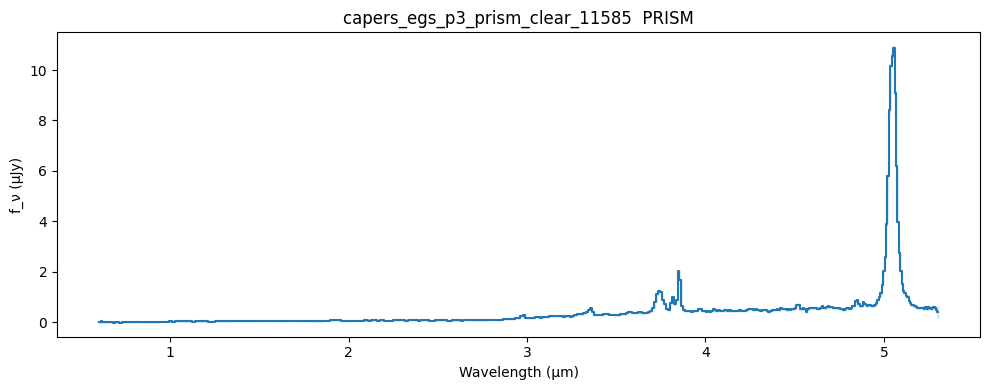

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
spec.plot(ax=ax)
plt.tight_layout()
plt.savefig('/tmp/cf_fig_spec_plot.png', dpi=150, bbox_inches='tight')
plt.show()


For full control, access the underlying numpy arrays directly:


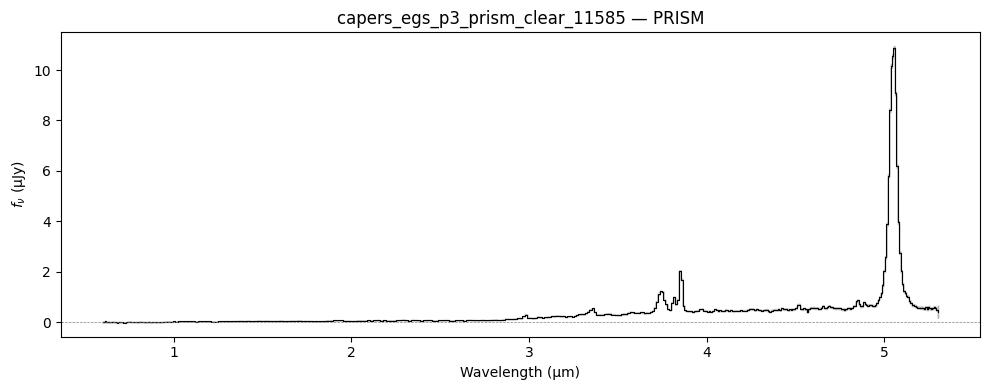

In [13]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4))
good = np.isfinite(spec.fnu) & np.isfinite(spec.fnu_err) & (spec.fnu_err > 0)
ax.step(spec.wavelength[good], spec.fnu[good], where='mid', lw=0.8, color='k')
ax.fill_between(
    spec.wavelength[good],
    spec.fnu[good] - spec.fnu_err[good],
    spec.fnu[good] + spec.fnu_err[good],
    step='mid', alpha=0.2, color='k',
)
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel(r'$f_\nu$ (μJy)')
ax.set_title(f'{spec.spectrum_id} — {spec.grating}')
ax.axhline(0, color='gray', lw=0.5, ls='--')
plt.tight_layout()
plt.show()


## 5. NIRCam cutout

`plot_cutout()` produces a publication-quality RGB image with vector
shutter overlays. Both the cutout PNG and shutter geometry are cached
locally after the first fetch.


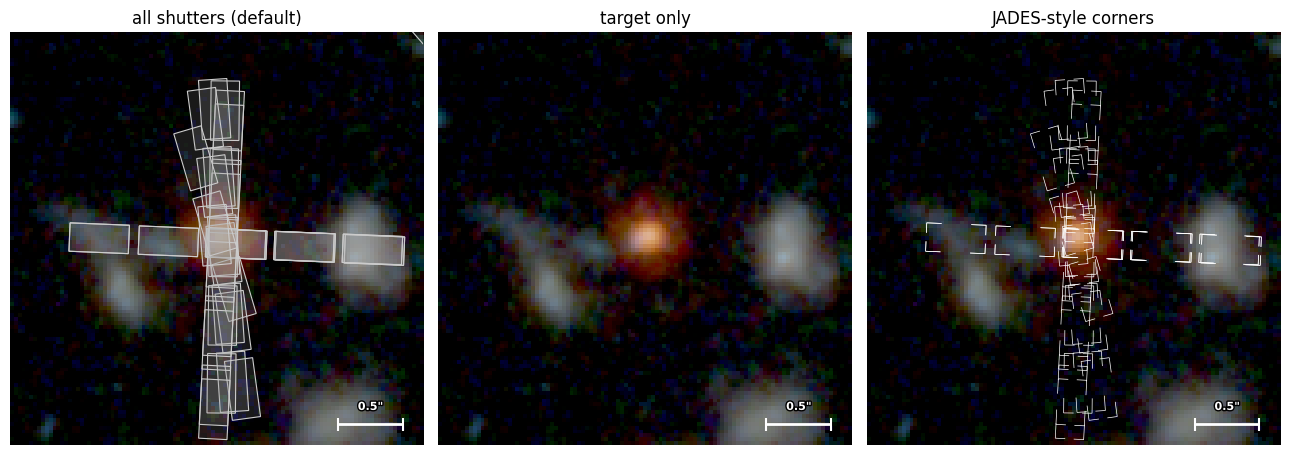

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

cf.plot_cutout('J141934.14+525238.7', fov=3.2, ax=axes[0])
axes[0].set_title('all shutters (default)')

cf.plot_cutout('J141934.14+525238.7', fov=3.2, shutters='target', ax=axes[1])
axes[1].set_title('target only')

cf.plot_cutout('J141934.14+525238.7', fov=3.2, ax=axes[2], shutter_style={
    'target': {'marker': 'corners', 'edgecolor': 'cyan', 'linewidth': 1.5},
    'other':  {'marker': 'corners', 'edgecolor': 'white', 'linewidth': 0.5},
})
axes[2].set_title('JADES-style corners')

plt.tight_layout()
plt.savefig('/tmp/cf_fig_cutout.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Bulk download FITS files

`cf.download()` is the same operation as `campfire download` on the CLI.
Use it any time you want bulk access; once files are local,
`open_spectrum` finds them automatically.

```python
# By observation
cf.download(observations=['rubies_egs_p63'])

# By program + grating
cf.download(programs=['rubies'], gratings=['PRISM'])

# By field
cf.download(fields=['cosmos'])

# Re-download files that have been reprocessed on the server
cf.download(stale_only=True)
```


---

# Recipes

End-to-end examples for common analysis tasks.


## Filter by data quality

`DQFlags` provides numpy-style operators for the per-spectrum data-quality
bitmask. Use `~DQFlags.X & ~DQFlags.Y` to exclude flags (the form
`~(X | Y)` is not supported).


In [15]:
from campfire import DQFlags, list_flags

# Show all available DQ flags
list_flags('dq_flags')



DQFlags:
  CHIP_GAP               = 1     # 
    Data quality flags.

    These flags indicate potential issues with the spectral data
    that may affect scientific analysis.
    
  CONTAMINATION          = 2     # 
    Data quality flags.

    These flags indicate potential issues with the spectral data
    that may affect scientific analysis.
    
  STUCK_SHUTTER          = 4     # 
    Data quality flags.

    These flags indicate potential issues with the spectral data
    that may affect scientific analysis.
    
  MULTIPLE_SOURCES       = 8     # 
    Data quality flags.

    These flags indicate potential issues with the spectral data
    that may affect scientific analysis.
    
  NO_DETECTION           = 16    # 
    Data quality flags.

    These flags indicate potential issues with the spectral data
    that may affect scientific analysis.
    
  LOW_SNR                = 32    # 
    Data quality flags.

    These flags indicate potential issues with the spectral data
    

In [16]:
# Clean PRISM spectra of inspected objects
clean = cf.query_spectra(
    gratings=['PRISM'],
    inspected_only=True,
    dq_flags=~DQFlags.CONTAMINATION & ~DQFlags.LOW_SNR,
)
print(f"{len(clean)} clean PRISM spectra of inspected objects")
clean['spectrum_id', 'signal_to_noise', 'redshift_auto'][:8]


9072 clean PRISM spectra of inspected objects


spectrum_id,signal_to_noise,redshift_auto
str38,float64,object
canucs_a370_p1_prism_clear_2105635,16.9799575805664,7.8676498441685
canucs_a370_p1_prism_clear_2107162,94.4910736083984,3.13470214939785
canucs_a370_p1_prism_clear_2108376,9.86572170257568,7.86144036709065
canucs_a370_p1_prism_clear_2108450,19.5652332305908,7.86321405957969
canucs_a370_p1_prism_clear_2114546,14.244481086731,7.74982662104508
canucs_a370_p2_prism_clear_2101179,27.0268592834473,7.6468263706549
canucs_a370_p2_prism_clear_2101240,98.7556762695312,3.01750904204109
canucs_a370_p2_prism_clear_2105635,11.7425947189331,7.86232716896216


## Iterate large samples

`iter_objects()` / `iter_spectra()` stream through all matching rows
without loading everything into memory.


In [17]:
# Count Hα emitters across the full catalog
n = sum(1 for _ in cf.iter_objects(tags=['hae']))
print(f"{n} Hα emitters")

# Or collect into a list
lae_list = list(cf.iter_objects(tags=['lae'], redshift_range=(4, 8)))
print(f"{len(lae_list)} LAEs at 4 < z < 8")


687 Hα emitters
115 LAEs at 4 < z < 8


## Cross-match with an external catalog

Use astropy's `match_to_catalog_sky` to find CAMPFIRE counterparts for
your own catalog.


In [18]:
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u

# CAMPFIRE objects in EGS
campfire_egs = cf.query_objects(fields=['egs'])

# A toy external catalog (replace with your own)
external = Table({
    'id':  ['src1', 'src2', 'src3'],
    'ra':  [214.892, 214.880, 214.910],
    'dec': [52.876, 52.880, 52.872],
})

ext_coords = SkyCoord(ra=external['ra'] * u.deg, dec=external['dec'] * u.deg)
cf_coords = SkyCoord(
    ra=campfire_egs['ra'] * u.deg,
    dec=campfire_egs['dec'] * u.deg,
)

idx, sep, _ = ext_coords.match_to_catalog_sky(cf_coords)
matched = sep < 1 * u.arcsec

matches = Table({
    'external_id'      : external['id'][matched],
    'campfire_id'      : campfire_egs['object_id'][idx[matched]],
    'separation_arcsec': sep[matched].to(u.arcsec).value.round(3),
    'redshift'         : campfire_egs['redshift'][idx[matched]],
})
print(f"Matched {len(matches)} / {len(external)} sources within 1\"")
print(matches)


Matched 0 / 3 sources within 1"
external_id campfire_id separation_arcsec redshift
----------- ----------- ----------------- --------


## Calibrate and stack PRISM spectra

`calibrate_and_stack` calibrates each spectrum to the object's photometry,
resamples them onto a common wavelength grid, and combines them. Useful
for combining repeated visits or low-SNR exposures.

Requires the `[deploy]` extra: `pip install -e ".[deploy]"`.


Stacking 2 PRISM spectra of J141934.14+525238.7


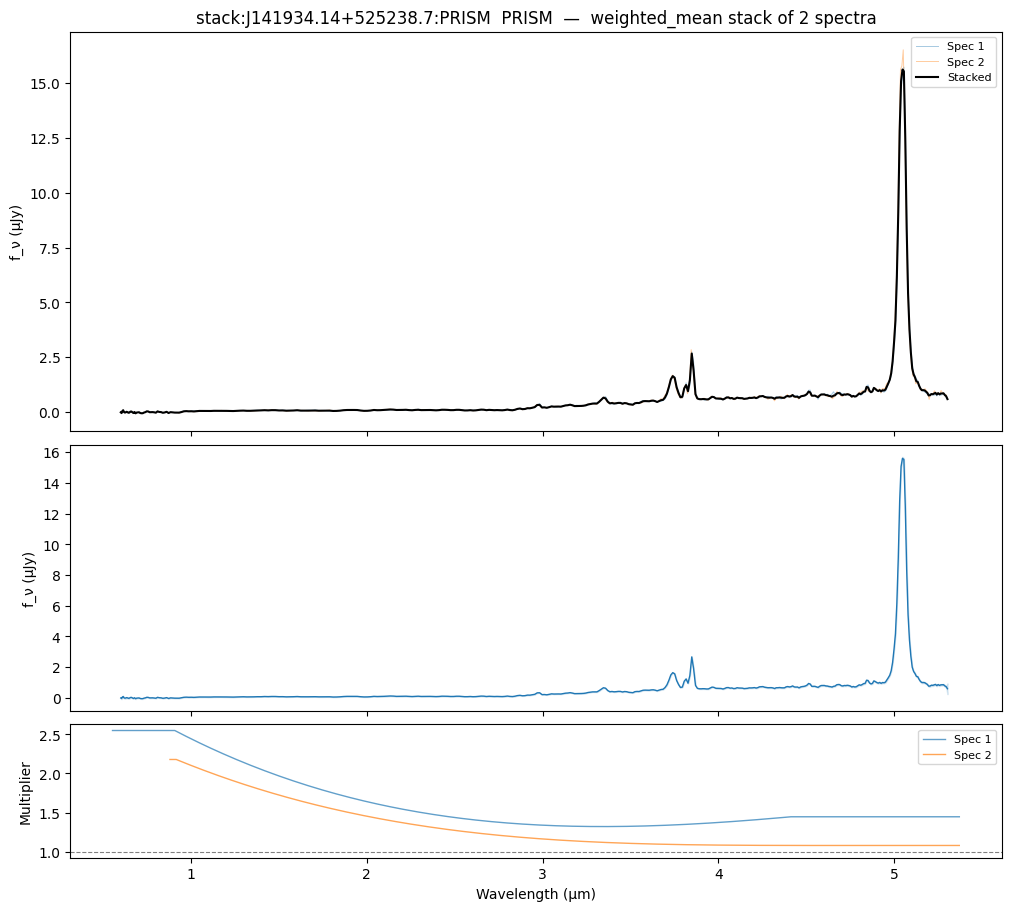

In [19]:
from campfire import calibrate_and_stack

obj = cf.get_object('J141934.14+525238.7')
prism = obj.spectra[obj.spectra.grating == 'PRISM']
print(f"Stacking {len(prism)} PRISM spectra of {obj.object_id}")

result = calibrate_and_stack(
    prism,
    photometry=obj.photometry,
    method='chebyshev',
    stacking_method='weighted_mean',
    object_id=obj.object_id,
)

result.plot()
plt.savefig('/tmp/cf_fig_stack.png', dpi=150, bbox_inches='tight')
plt.show()


## SED + spectrum overlay

Show broadband photometry and a spectrum on the same axes — useful for
quick consistency checks.


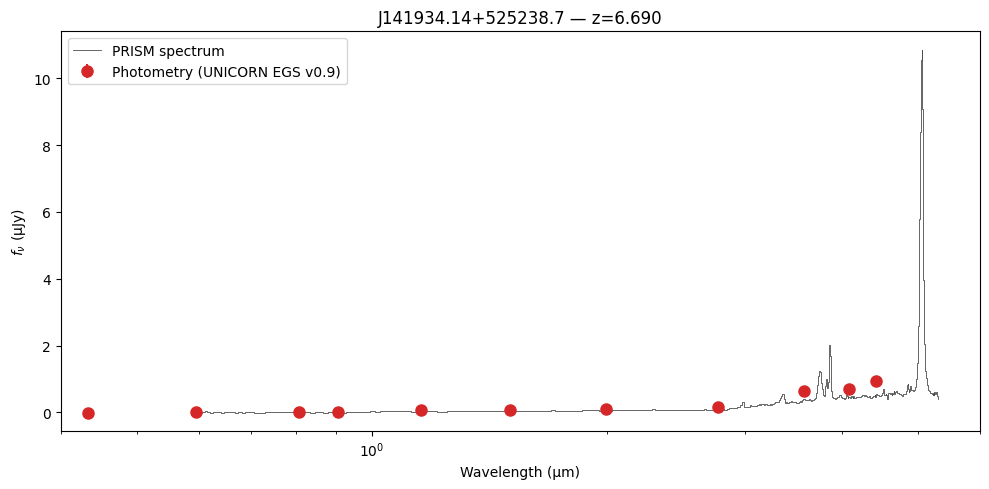

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

# Spectrum (μJy)
spec = cf.open_spectrum('capers_egs_p3_prism_clear_11585')
good = np.isfinite(spec.fnu) & (spec.fnu_err > 0)
ax.step(spec.wavelength[good], spec.fnu[good], where='mid',
        lw=0.6, color='k', alpha=0.7, label='PRISM spectrum')

# Photometry
phot = obj.photometry
ax.errorbar(phot.wavelength, phot.flux, yerr=phot.flux_err,
            fmt='o', ms=8, color='C3', ecolor='C3',
            label=f'Photometry ({phot.catalog})', zorder=5)

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel(r'$f_\nu$ (μJy)')
ax.set_xscale('log')
ax.set_xlim(0.4, 6.0)
ax.set_title(f'{obj.object_id} — z={obj.redshift:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/cf_fig_sed.png', dpi=150, bbox_inches='tight')
plt.show()


## CSV-only workflow

After every `cf.sync()`, the catalog is also exported to plain CSV files
in `$CAMPFIRE_ROOT/meta/` (or `~/campfire/meta/`). You can use these with
pandas/astropy without any client involvement.


In [21]:
import os
from pathlib import Path
from astropy.table import Table

meta = Path(os.environ.get('CAMPFIRE_ROOT', Path.home() / 'campfire')) / 'meta'

objects = Table.read(meta / 'objects.csv')
spectra = Table.read(meta / 'spectra.csv')

print(f"objects.csv : {len(objects):>5} rows")
print(f"spectra.csv : {len(spectra):>5} rows")

mask = (objects['redshift'] > 5.0) & (objects['redshift_quality'] >= 3)
print(f"\n{mask.sum()} objects at z>5 with quality≥3")


objects.csv : 32796 rows
spectra.csv : 47340 rows

2369 objects at z>5 with quality≥3


---

## Summary

| Method | Purpose |
|---|---|
| `cf.sync()` | Pull full catalog (metadata only, fast) |
| `cf.download()` | Bulk-download FITS by obs/program/field/grating |
| `cf.query_objects()` | One row per sky position; inspection state lives here |
| `cf.query_spectra()` | One row per spectrum; per-spectrum dq_flags here |
| `cf.iter_objects()` / `iter_spectra()` | Stream large result sets |
| `cf.get_object()` | Typed `Object` with `.spectra` + `.photometry` |
| `cf.open_spectrum()` | Load FITS arrays as `SpectrumData` |
| `cf.plot_cutout()` | RGB cutout with vector shutter overlay |
| `calibrate_and_stack()` | Calibrate to photometry → resample → stack |

See the [docs](https://campfire.hollisakins.com/docs/api) for the full reference.
